# Generation of Events

## Load Libraries

In [1]:
try: import pythia8
except: 
    try: import pythia8mc as pythia8
    except: print('Cannot import neither pythia8 nor pythia8mc module')

In [2]:
import os
import matplotlib 
from multiprocessing import Process, Pool, cpu_count
from scipy.interpolate import interp1d,LinearNDInterpolator

import pandas as pd
import numpy as np

from matplotlib import pyplot as plt 

## Shower Model

### Expressions

**Bremsstrahlung** The cross section for $e^\pm$ Bremmsstrahlung, is given by Eq. (34.29) of [PDG2022](https://pdg.lbl.gov/2022/reviews/rpp2022-rev-passage-particles-matter.pdf) which, with slight notational modifications, reads

\begin{equation}
\frac{d\sigma(e^\pm \to e^\pm \gamma)}{dx} = \frac{A}{X_0 N_A} \frac{1}{x} \left( \frac{4}{3} - \frac{4}{3}x + x^2 \right),
\end{equation}

where $A$ is the atomic mass of the absorber [AMU, or g/mol], $X_0$ is the radiation length and $N_A$ is Avogadro's number, and $x$ is the fraction of the original lepton's energy transferred to the radiated photon.

**Pair Production** Similarly, photon pair production is given by Eq. (34.31) of [PDG2022](https://pdg.lbl.gov/2022/reviews/rpp2022-rev-passage-particles-matter.pdf)

\begin{equation}
\frac{d\sigma(\gamma \to e^+e^-)}{dx} = \frac{A}{X_0 N_A} \left( 1 - \frac{4}{3}(x - x^2) \right)
\end{equation}

where $x$ is the fractions of energy obtained by either the electron or positron, and the other one will inherit $1-x$. 
It doesn't matter which way these are assigned, as the cross section is symmetric about $x=1/2$.

The factor $A/(X_0 N_A)$ appearing in both of these equations can be set to unity, as the cross section will be used for MC sampling, and the factor just contributes to normalization when we sample a cross section value within some sampling interval.

**$z$ sampling**

The radiation length must enter the sampling of $z$ coordinates, and this is done by demanding that the shower algorithm reproduces the defining feature of radiation length $X_0$: after traveling through $X_0$ in matter, the electron must be left with a fraction of $1/e$ of its original energy, where $e$ is Neper's constant. Below, the electron's remaining energy fraction is denoted $x_1$, and it loses $1-x_1 \equiv x_2$, which is the fraction obtained by the photon. This means that when traveling $X_0$, the loss $x_2$ must be comparable to $1-1/e$. Hence we sample the step size in $z$ from an exponential distribution with the scale factor $X_0 x_2 (1-1/e)$.

In this case, it can be seen that 

\begin{equation}
\frac{d\sigma(\gamma \to e^+e^-)}{dx} \in [2/3, 1] 
\quad{\rm and}\quad 
\frac{d\sigma(e^\pm \to e\pm \gamma)}{dx} \in [1, \infty[ \quad \forall~x \in ]0,1[.
\end{equation}

Note that strictly speaking the cases $x=0$ and $x=1$ would not be valid. 
Also, the Bremmsstrahlung cross section diverges as $x \to 0$.
We will therefore introduce cuts on $x$

**Improved Bremsstrahlung** To avoid the singularity at $x=0$ we use the result presented in  
[hep-ph/9802442](https://arxiv.org/pdf/hep-ph/9802442): 

\begin{equation}
\frac{d\sigma_{LPM}(e^\pm \to e\pm \gamma)}{dx} =  \frac{A}{X_0 N_A} \frac{1}{3x} \left( x^2 G(s) + 2[1+(1-x)^2] \phi(x)\right).
\end{equation}

For $G=\phi=1$ this reproduces the previous approximation. Following Eq (78), we define 

\begin{equation}
s(x)= \sqrt {\frac{E_{LPM} x}{8E(1-x) \xi(s'(x))} } \qquad  \text{and} \qquad s'(x)= \sqrt {\frac{E_{LPM} x}{8E(1-x)}}
\end{equation}

where $E_{LPM} = 7.7\text{ TeV/cm} \times X_0 = 323$ TeV for plastic with $X_0=42$ cm. We further define $s_1 = Z^{2/3}/184^2 \approx 10^{-4}$ for tungsten, $h=\ln s' / \ln \sqrt{2}s_1$  and 

\begin{equation}
\xi(s') = 
2 \text { (for $s'<\sqrt{2} s_1$),} \qquad  
1+h+\frac{0.08(1-h)[1-(1-h)^2]}{\ln \sqrt{2}s_1} \text { (for $\sqrt{2} s_1<s'<1$), and} \qquad 
1 \text { (for $s'>1$)}
\end{equation}

We can now define

\begin{eqnarray}
\phi(s) & = & 1-\exp{\bigg(-6s[1+(3-\pi)s]+s^3/(0.623+
0.796s+0.658s^2)\bigg)}\nonumber\\ 
\psi(s) & = & 1-\exp{\bigg(-4s-8s^2/(1+3.96s+4.97s^2-0.05s^3+7.5s^4)} \bigg)
\nonumber\\
G(s) & =  & 3\psi(s)-2\phi(s).
\end{eqnarray} 

Let us now code up everything. 

In [3]:
def func_sp(x, E): 
    E_lpm = 323e3
    return np.sqrt(E_lpm * x / 8 / E / (1-x))

def func_xi(x, E):
    sqrt2s1 = 1e-4 * np.sqrt(2)
    sp = func_sp(x,E)
    if sp < sqrt2s1: return 2
    if sp > 1: return 1
    h = np.log(sp)/np.log(sqrt2s1)
    return 1+h+0.08*(1-h)*(1-(1-h)**2)/np.log(sqrt2s1) 

def func_s(x, E): 
    E_lpm = 323e3
    return np.sqrt(E_lpm * x / 8 / E / (1-x) * func_xi(x,E))

def func_phi(x,E):
    s = func_s(x,E)
    if s>2: return 1
    value = -6*s*(1+(3-np.pi)*s)+s**3/(0.623+0.796*s+0.658*s**2)
    return 1-np.exp(value)

def func_psi(x,E):
    s = func_s(x,E)
    if s>2: return 1
    value = -4*s - 8*s**2/(1+0.396*s+0.497*s**2-0.05*s**3+7.5*s**4)
    return 1-np.exp(value)

def func_g(x,E):
    return 3*func_phi(x,E) - 2*func_psi(x,E)

def dsigmadx(x=0.5,E=1000,mode='brem_lpm'):
    if mode=='brem_bh': 
        return 1./x*(4/3. - 4./3*x + x**2)
    elif mode == 'brem_lpm':
        return 1/(3.*x)*(x**2*func_g(x,E)+2*(1+(1-x)**2)*func_phi(x,E))
    if mode=='pair':      
        return (1. - 4./3.*(x - x*x))      

We now plot the cross sections:

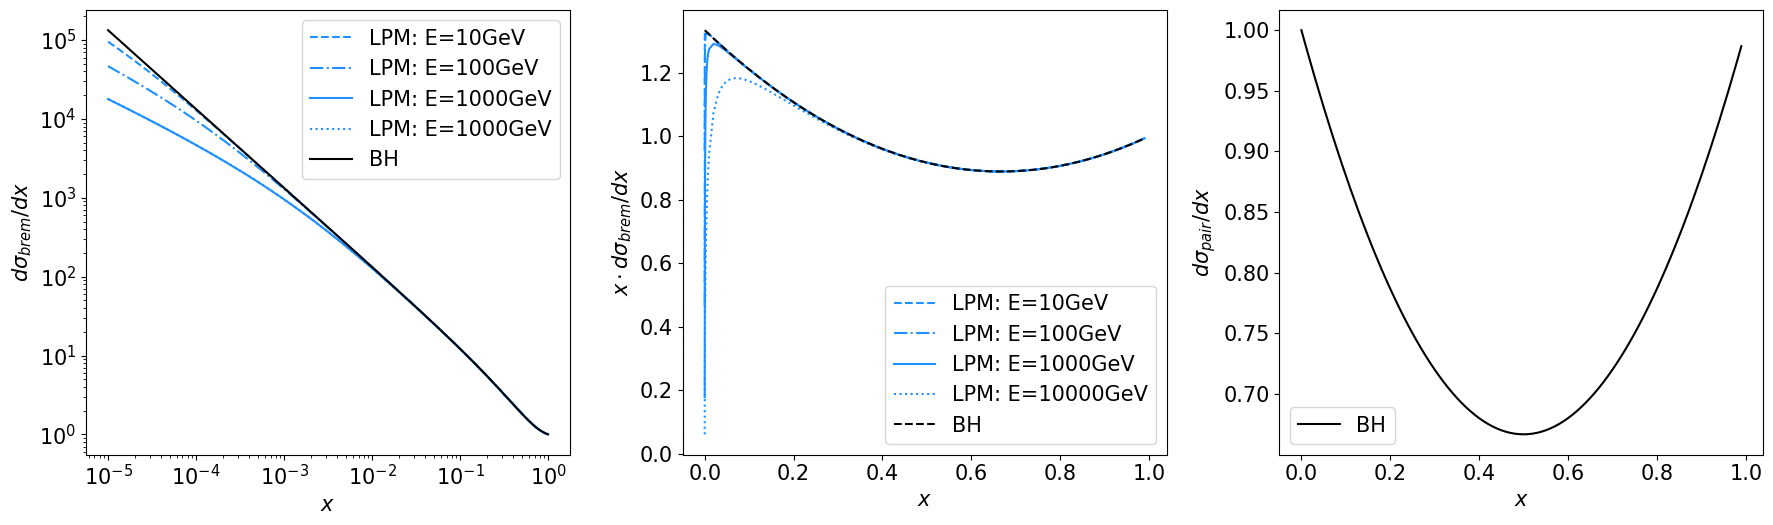

In [4]:
matplotlib.rcParams.update({'font.size': 15})
fig = plt.figure(figsize=(18,5.5))
xvals = list(np.logspace(-5, -2, 30)) + list(np.linspace(0.01, 0.99, 99))

ax = plt.subplot(1,3,1)
for E, ls in zip([10,100,1000,1000], ["dashed", "dashdot", 'solid', 'dotted']):
    yvals = [dsigmadx(x=x,E=E, mode='brem_lpm') for x in xvals]
    ax.plot(xvals, yvals, ls=ls, c='dodgerblue', label=r'LPM: E='+str(E)+'GeV')
yvals = [dsigmadx(x=x,E=E, mode='brem_bh') for x in xvals]
ax.plot(xvals, yvals, ls='solid', c='k', label=r'BH')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$d\sigma_{brem}/dx$')
ax.legend()
                 
ax = plt.subplot(1,3,2)
for E, ls in zip([10,100,1000,10000], ["dashed", "dashdot", 'solid', 'dotted']):
    yvals = [x*dsigmadx(x=x,E=E, mode='brem_lpm') for x in xvals]
    ax.plot(xvals, yvals, ls=ls, c='dodgerblue', label=r'LPM: E='+str(E)+'GeV')
yvals = [x*dsigmadx(x=x,E=E, mode='brem_bh') for x in xvals]
ax.plot(xvals, yvals, ls='dashed', c='k', label=r'BH')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$x \cdot d\sigma_{brem}/dx$')
ax.legend()

ax = plt.subplot(1,3,3)
yvals = [dsigmadx(x=x,E=E, mode='pair') for x in xvals]
ax.plot(xvals, yvals, ls='solid', c='k', label=r'BH')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$d\sigma_{pair}/dx$')
ax.legend()

plt.tight_layout()
plt.show()

This agrees with the results shown in Figure 34.12 and 34.18 of [PDG2022](https://pdg.lbl.gov/2022/reviews/rpp2022-rev-passage-particles-matter.pdf). 

### Sampling

A simple CDF based sampling algorithm. First, evaluate all CDFs (for the LPM case in 10 GeV steps) and use them later. 

In [5]:
# define xgrid
x_grid = np.linspace(0.01, 0.99, 300)

# results for pair
pdf = np.array([dsigmadx(x,E=1000,mode='pair') for x in x_grid])
pdf[pdf < 0] = 0.0
cdf_pair = np.cumsum(pdf)
cdf_pair /= cdf_pair[-1]

# results for brem_bh
pdf = np.array([dsigmadx(x,E=1000,mode='brem_bh') for x in x_grid])
pdf[pdf < 0] = 0.0
cdf_bh = np.cumsum(pdf)
cdf_bh /= cdf_bh[-1]
    
# results for brem_lpm
cdf_lpm={}
for energy in np.linspace(10,10000, 1000):
    pdf = np.array([dsigmadx(x,E=energy,mode='brem_lpm') for x in x_grid])
    pdf[pdf < 0] = 0.0
    cdf = np.cumsum(pdf)
    cdf_lpm[energy] = cdf/cdf[-1]

In [6]:
def xsampling(mode, E=1000):
    
    if mode=='pair': 
        return np.interp(np.random.rand(), cdf_pair, x_grid)
    if mode=='brem_bh': 
        return np.interp(np.random.rand(), cdf_bh, x_grid)
    if mode=='brem_lpm' and E<=10: 
        return np.interp(np.random.rand(), cdf_bh, x_grid)
    if mode=='brem_lpm' and E>10: 
        energy = round(E/10)*10
        return np.interp(np.random.rand(), cdf_lpm[energy], x_grid)
    

To add transverse smearing, $p_T^2$ is sampled according to

\begin{equation}
p_T^2 = b((1 + p_{T{\rm ,max}}^2/b)^u - 1)
\end{equation}

which inverts the CDF of $1/(p_T^2 + b)$. 
Here, 
$u \in {\rm Uniform}[0,1]$, 
$p_{T{\rm ,max}} = x E \theta_{\rm max}$ 
and 
$b=x^2 m_e^2$ ($b=m_e^2$) for Bremmsstrahlung (pair production), with $\theta_{\rm max}=0.1$ based on the small angle approximation being good for angles below 0.1 rad.

For now we generate the random number u individually for both particles; these are not vacuum effects so we probably can't require back-to-back momenta and/or exact momentum conservation for the leptons and photons alone.**

Param:
- `x`:  Momentum fraction obtained by the daughter particle
- `e`:  Parent particle energy
- `b`:  The parameter b explained above

In [7]:
def ptsampling(x,e,b):
    me = 0.00051099895 
    thetamax = 0.1
    pTmax = min(me,x*e*thetamax)
    u = np.random.rand()  
    pT2 = b * ((1.0 + (pTmax*pTmax)/b)**u - 1.0)
    return np.sqrt(pT2)

### Mean free path for Bremsstrahlung

Compute the mean free path (MFP) to be used as the scaling parameter for sampling interaction vertex $z$ coordinates from an exponential distribution. The MFP will depend on the energy loss $x_2$, and will be shorter for small $x_2$.

This is inspired by the [PENELOPE-2018 manual](https://www.oecd-nea.org/upload/docs/application/pdf/2020-10/penelope-2018__a_code_system_for_monte_carlo_simulation_of_electron_and_photon_transport.pdf), where the inverse of the MFP Bremmstrahlung for a particle of energy $E$ is given as

\begin{equation}
\lambda_{\rm Br}^{-1}(E)
=
\mathcal{N}
\int_{W_{\rm cr}}^{E}
\frac{d\sigma_{\rm Br}}{dW}
dW,
\end{equation}

where $\sigma_{\rm Br}$ is the Bremsstrahlung cross section, and the integration variable $W$ covers all energies from a low-$E$ cutoff $W_{\rm cr}$ (needed e.g. in the BH case) to $E$, representing the energy of the radiated photon. 

In the present case, the available cross section is $d\sigma_{\rm Br}/dx$, so we use $dx$ instead of $dW$ (any factors introduced by the change of variables cancel each other, as we have one $dW$ in the denominator and in the numerator, whilte integration limits become $[x_{\rm cr}\to 0, 1]$, and the normalization is taken to be the radiation length, so that we have

\begin{equation}
\lambda_{\rm Br}^{-1}(E)
=
\frac{1}{X_0}
\int_{0}^{1}
\frac{d\sigma_{\rm Br}(E)}{dx}
dx.
\end{equation}

In [8]:
lambdaBr={}
def getMFP(X0,mode,e):
    
    global lambdaBr
    if X0 not in lambdaBr: lambdaBr[X0] = {}
    
    if mode not in lambdaBr[X0]:
        Ndx=200  #How many integration steps to take per energy
        xvals = np.linspace(0,1,Ndx)
        xvals = np.divide(np.add(xvals[:-1],xvals[1:]),2)  #Use "bin centers" instead of "edges"            
        dx = xvals[1]-xvals[0]
        energies = np.linspace(10,10000,1000)
        xsintinv=[]
        for energy in energies:
            xs = []
            for x in xvals:
                try: xs.append(dsigmadx(x=x,E=e,mode=mode))  #N.B. here we compute a grid, looping over energies
                except: xs.append(1.)
            xsint = sum(xs)*dx/X0
            try:    xsintinv.append(1./xsint)
            except: xsintinv.append(X0)    
        lambdaBr[X0][mode] = interp1d(energies,xsintinv,fill_value='extrapolate')

    return lambdaBr[X0][mode](e)  #N.B. only here we need to evaluate at requested energy e, in case xsec is dependent on it        

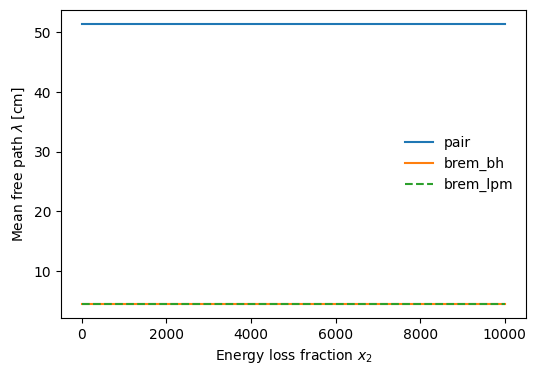

In [9]:
#Setup figure
matplotlib.rcParams.update({'font.size': 10})
matplotlib.rcParams['text.usetex'] = False
fig = plt.figure(figsize=(6,4))
ax = plt.subplot(1,1,1)
energies = np.linspace(10,10000,1000)
ax.plot(energies,[getMFP(X0=40., mode='pair',     e=e) for e in energies],label='pair')
ax.plot(energies,[getMFP(X0=40., mode='brem_bh',  e=e) for e in energies],label='brem_bh')
ax.plot(energies,[getMFP(X0=40., mode='brem_lpm', e=e) for e in energies],label='brem_lpm',   linestyle='dashed')
ax.set_ylabel(r'Mean free path $\lambda$ [cm]')
ax.set_xlabel(r'Energy loss fraction $x_2$')
ax.legend(frameon=False)

The above plot illustrates the difference between $X_0$ and the MFP $\lambda$: although $X_0=40$~cm is the input scale for all computations, the pair production case yields $\lambda \approx 9/7 X_0$ as expected. For Bremsstrahlung, the MFP turns out significantly smaller than $X_0$, illustrating that many Bremsstrahlung interactions can take place within a single $X_0$; the radiation length is not the scale of interactions, but of accumulated energy loss. For photons this issue is not so drastic, as pair production is destructive to the original photon, so the scale entering the exponential $z$-coordinate distribution is more clearly immediately the scale of interactions. For $e^\pm$, we need to decrease the scale down from $X_0$ to $\lambda$ in order to get to the level of individual interactions, required for $z$ sampling. 

### Shower Algorithm

Now define the shower algorithm with MC sampling of the momentum fractions based on the cross sections above. The parameters are
- `pid`: incoming particle PDG ID: $e^\pm$ lose energy via bremmstrahlung, $\gamma$ may pair-produce $e^+,e^-$. Others irrelevant here.
- `px,py,pz,e`: incoming particle 4-momentum components in [GeV]
-  `z0`: the location of the particle vs the end of the detector, expect negative values in [cm]
-  `X0cm`: radiation length [cm], default: 40 cm for plastic

In [10]:
def shower(pid, px,py,pz,e, z0, X0cm=40, A=12.):
    
    # if not electron or photon, don't do anything
    if pid not in [11,-11,22]: return [[pid,px,py,pz,e]]
    
    # constants assuming a plastic/carbon target
    X0=X0cm  # radiation length in cm
    #if pid==22: X0*=9./7.  # for photons X0 -> 9/7 X0 -- DO NOT USE IF z SAMPLING IS BASED ON lambdaBr! It already accounts for this.
    me = 0.00051099895 # electron mass
        
    # init momentum fraction of the radiated photon, or one of the pair produced particles, corresponds to 'y' or 'x' in literature
    x2 = 0.
    
    # photons: pair production of e^+,e^-
    if pid==22:
        mode='pair'
        pid1,pid2=11,-11
    # e^+/-: #bremmsstrahlung produces original particle w/ changed energy + photon
    else:
        #mode='brem_bh'
        mode='brem_lpm'
        pid1,pid2=pid,22
    x2 = xsampling(mode=mode, E=e)  # the photon bremmsstrahled by the electron, or one of the pair-produced leptons
    x1 = 1.-x2  # the other particle will inherit the remainder of the original momentum
    
    # advance z-coordinate based on mean free path
    lambdaBr = getMFP(X0=X0,mode=mode,e=e)
    z = z0 + np.random.exponential(scale=lambdaBr)
    
    # if z>0 or low energy, particle did not interact, return particle
    if z>0 or e<1: return [[pid,px,py,pz,e]]

    
    # transverse momentum smearing: init both pT in opposite directions along a single axis, rotate later
    pT1 = np.array([ ptsampling(x=x1,e=e,b=me*me*x1*x1 if mode=='pair' else me*me), 0.])
    pT2 = np.array([-ptsampling(x=x2,e=e,b=me*me*x2*x2 if mode=='pair' else me*me), 0.])
    phi = 2.*np.pi*np.random.rand()
    rot = np.matrix([[np.cos(phi), -np.sin(phi)], [np.sin(phi),  np.cos(phi)]])
    pT1 = np.matmul(rot,pT1).tolist()[0]  # matmul seems to add brackets around the result, remove those and turn from np.array to list
    pT2 = np.matmul(rot,pT2).tolist()[0]
    # N.B. the pT-smearing is simply added to the final result below, as it is expected to be small.
    # Though seemingly violates momentum conservation, note that Bremmsstrahlung and pair production are not vacuum effects.
    
    # apply recursively to the produced particles
    parts1 = shower(pid=pid1, px=(x1*px+pT1[0]), py=(x1*py+pT1[1]), pz=(x1*pz), e=(x1*e), z0=z, X0cm=X0cm)
    parts2 = shower(pid=pid2, px=(x2*px+pT2[0]), py=(x2*py+pT2[1]), pz=(x2*pz), e=(x2*e), z0=z, X0cm=X0cm)
    return parts1+parts2

Let's look at an example: process a few TeV energy electrons 

In [11]:
for _ in range(20):
    shwr = shower(px=0,py=0,pz=1000,e=1000,pid=11,z0=-20,X0cm=40.)
    #print (shwr)                   #Print the IDs and 4-vectors of all particles returned by the showering algorithm
    print ([[s[0],float(round(s[-1],3))] for s in shwr])    #Print PDG IDs and energies
    #print ([s[0] for s in shwr])    #Print PDG IDs only

[[11, 316.129], [22, 267.606], [22, 308.481], [22, 23.144], [22, 22.924], [22, 61.716]]
[[11, 221.525], [22, 13.409], [22, 751.805], [22, 13.261]]
[[11, 768.966], [22, 17.293], [22, 203.741], [22, 10.0]]
[[11, 585.766], [22, 333.517], [11, 10.118], [22, 0.267], [22, 0.343], [-11, 0.476], [22, 10.307], [22, 2.307], [22, 3.974], [11, 2.419], [22, 1.678], [22, 0.583], [22, 0.295], [22, 0.069], [22, 0.971], [-11, 2.619], [22, 0.062], [22, 0.027], [22, 0.185], [22, 0.151], [22, 0.507], [22, 15.058], [11, 19.175], [-11, 8.156], [22, 0.862], [22, 0.109]]
[[11, 381.152], [22, 507.874], [22, 54.56], [22, 9.531], [22, 46.883]]
[[11, 774.847], [22, 45.125], [22, 110.564], [11, 29.103], [22, 3.364], [-11, 36.998]]
[[11, 484.785], [22, 133.335], [22, 6.244], [22, 63.923], [11, 142.126], [22, 33.039], [-11, 136.547]]
[[11, 834.531], [22, 32.799], [22, 55.757], [22, 57.658], [22, 19.255]]
[[11, 511.282], [22, 40.586], [22, 75.789], [22, 13.68], [11, 1.662], [22, 4.028], [22, 0.293], [-11, 11.559], [2

Check if the showering produces the expected exponential distribution. This is done by finding the number of photons and electrons `Negamma` (result of the shower output) `Nsample` number of times and weigh by `1/Nsample` to get an average. The results are plotted against `z0`, the depth at which the interaction took place (not integrating over a total detector depth here).

In [12]:
def checkShowerEloss(Ee):
    Nsample=200
    z0range = np.linspace(-200,0,30)
    Negamma,Ngamma,Ne = [],[],[]
    elead=[]  #Leading electron energies
    einit=[]  #First/initial electron energies
    for z0 in z0range:
        Negammatmp,Ngammatmp,eleadtmp,einittmp = 0,0,0,0
        for nsample in range(Nsample):
            shwr = shower(px=0,py=0,pz=Ee,e=Ee,pid=11,z0=z0,X0cm=40.)
            eleadtmp += max([s[-1] for s in shwr if abs(s[0])==11])  #Find highest electron energy
            einittmp += shwr[0][-1]  #First electron energy
            Negammatmp += len(shwr)  #number of photons and electrons
            Ngammatmp  += len([s for s in shwr if s[0]==22])  #number of photons
        Negamma.append(Negammatmp/Nsample)
        Ngamma.append( Ngammatmp /Nsample)
        Ne.append(Negamma[-1]-Ngamma[-1])
        elead.append(eleadtmp/Nsample)
        einit.append(einittmp/Nsample)
    
    #Setup figure
    matplotlib.rcParams.update({'font.size': 10})
    matplotlib.rcParams['text.usetex'] = False
    fig = plt.figure(figsize=(8,4))

    ax = plt.subplot(1,2,1)   
    ax.plot(z0range,elead,label=r'Shower, leading $e$')
    ax.plot(z0range,einit,label=r'Shower, initial $e$')
    #ax.plot([0,-40,-80,-160],[Ee*np.power(1-1/np.e,n) for n in range(4)],label='1-1/e loss')
    ax.plot([0,-40,-80,-160],[Ee*np.power(1/np.e,n) for n in range(4)],label='(1/e)^n fractions of energy')
    ax.plot(z0range,[Ee*np.exp(z0/40) for z0 in z0range],label='Exp(z0/40)')
    ax.set_xlabel(r'$z_0$ [cm]')
    ax.set_ylabel(r'$E_e$ [GeV]')
    ax.legend(frameon=False)

    ax = plt.subplot(1,2,2)
    ax.plot(z0range,Negamma,label=r'$\gamma + e^\pm$')
    ax.plot(z0range,Ngamma, label=r'$\gamma$')
    ax.plot(z0range,Ne,     label=r'$e^\pm$')
    ax.set_xlabel(r'$z_0$ [cm]')
    ax.set_ylabel(r'#particles')
    ax.legend(frameon=False)


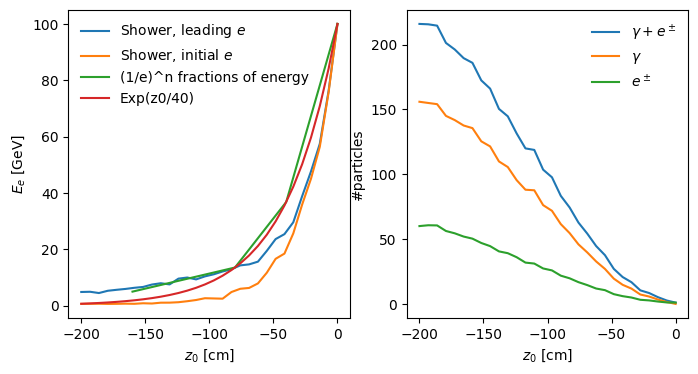

In [13]:
checkShowerEloss(Ee=100.)

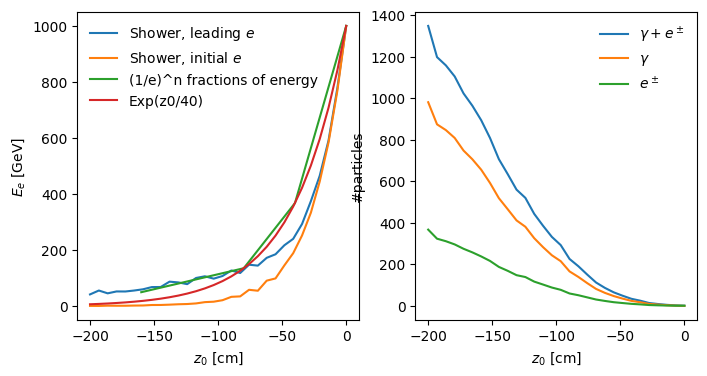

In [14]:
checkShowerEloss(Ee=1000.)

In [15]:
%%time
for _ in range(10000): _=shower(px=0,py=0,pz=1000,e=1000,pid=11,z0=-20,X0cm=40.) 

CPU times: user 3.05 s, sys: 1 ms, total: 3.05 s
Wall time: 3.05 s


## Function that Generates Events

The following function generates a set of `nevent_mc` events for incoming neutrinos with a PID `vpid` and fixed energy `energy` undergoing an NC/CC scattering `process`. The events are weighted, such that the sum of weights is `nevent_physical`. Events are stored in a `csv` file, where each event consists of a sum of particles characterized by
- the event number `ievent`
- the particle number `iparticle`
- the neutrino energy `truth_energy` in GeV
- the particle ID `pid`
- the particle momenta/energy `px`, `py`, `pz`, `e` in GeV
- the vertex position `x`, `y`, `z` in cm
- the event weight `weight` in physical events

In [16]:
def generate_events(
        energy, 
        nevent_mc=100, 
        nevent_physical=1, 
        level='hadron', 
        target='C', 
        process='CC', 
        vpid='14', 
        user="Toni",
        #user="Felix",
        width=300, 
        height=100, 
        depth=20,
        X0=40.,
        verbose=False
    ):

    # Ensure output destination exists
    if not os.path.exists('events'): os.mkdir('events')
    
    # Setup Pythia
    pythia = pythia8.Pythia()
    
    # Suppress output
    if not verbose: pythia.readString("Print:quiet = on")
    
    # Set random seeds
    pythia.readString("Random:setSeed=on")
    pythia.readString("Random:seed=0")

    # Define beams (frameType = 2 for fixed target collisions)
    pythia.readString("Beams:frameType = 2")
    pythia.readString("Beams:eA = "+str(energy))
    pythia.readString("Beams:eB = 0")

    # Use the nuclear PDF nCTEQ15 for Tungsten (A=184, Z=74)
    if target == 'W':
        pdffile = "nCTEQ15FullNuc_184_74_0000.dat"
    elif target == 'Fe':
        pdffile = "nCTEQ15FullNuc_56_26_0000.dat"    
    elif target == 'C':
        pdffile = "nCTEQ15FullNuc_12_6_0000.dat"    
    
    if user=="Felix": 
        pdfpath = "/Users/felixkling/work/LHAPDF-6.2.1/installed/share/LHAPDF/" + pdffile[:-9] + "/"
    elif user=="Toni": 
        pdfpath = "/home/user/install/LHAPDF/share/LHAPDF/" + pdffile[:-9] + "/"
    pythia.readString("PDF:pSet=LHAGrid1:" + pdfpath + pdffile)

    # Activate necessary options for Pythia
    pythia.readString("PDF:lepton = off")
    pythia.readString("TimeShower:QEDshowerByL = off")

    # Fix Renormalization/Factorization scale
    pythia.readString("SigmaProcess:factorScale2=6")
    pythia.readString("SigmaProcess:renormScale2=6")

    # Minimal phase space cuts
    pythia.readString("PhaseSpace:mHatMin=1")
    pythia.readString("PhaseSpace:pTHatMin=0")
    pythia.readString("PhaseSpace:pTHatMinDiverge=0.5")

    # Define process type 
    if process == "CC": pythia.readString("WeakBosonExchange:ff2ff(t:W)=on")
    elif process == "NC":  pythia.readString("WeakBosonExchange:ff2ff(t:gmZ)=on")
    else: print("Error: process_type = " + process + " is not valid.")
    
    # Set beam particle
    pythia.readString("Beams:idA = "+vpid)
    
    # Decide if shower and hadronization should be included
    if level == "hard":
        pythia.readString("HadronLevel:all=off")
        pythia.readString("PartonLevel:all=off")
    elif level == "parton":
        pythia.readString("HadronLevel:all=off")
        pythia.readString("PartonLevel:all=on")
    elif level == "hadron":
        pythia.readString("HadronLevel:all=on")
        pythia.readString("PartonLevel:all=on")
    else:
        print("Error: level = " + level + " is not a valid option")
        return False

    
    # Initialize Pythia
    pythia.init()
    
    # List to store events data for DataFrame
    events_data = []
        
    # Loop over events
    nevent_saved = 0  #Stepper to count the number of events actually processed
    nevent_loop = nevent_mc if nevent_physical>0 else 0  #Only loop events if they will have non-zero weights
    for ievent in range(nevent_loop):
        
        # Generate next event
        if not pythia.next(): continue  #Some events are discarded due to e.g. exhausting phase-space, or errors. Affects nevent_saved. 
        
        # Collect all particles in the event
        event_data = []
        
        #position
        x = round(np.random.uniform(-width/2, width/2),2)
        y = round(np.random.uniform(-height/2, height/2),2)
        z = round(np.random.uniform(-depth, 0),2)

        # loop over particles
        particles = pythia.process if level == "hard" else pythia.event
        for iparticle, particle in enumerate(particles):
            
            # Collect final-state particle data
            if particle.status() > 0:
                pid = particle.id()
                px = round(particle.px(), 2)
                py = round(particle.py(), 2)
                pz = round(particle.pz(), 2)
                e  = round(particle.e(),  2)
                
                # shower particle (does nothing except for pid = 11, -11, 22)
                parts = shower(pid, px,py,pz,e,z, X0cm=X0)
                    
                #store particle
                for pid, px, py, pz, e in parts:
                    events_data.append([ievent, iparticle, energy, pid, px, py, pz, e, x, y, z])   
        
        nevent_saved+=1

    #MC weights: all events in one file will have the same weight, computed from the physically expected events vs how many were stored
    weight = nevent_physical/float(nevent_saved) if nevent_saved>0 else 0
    for i in range(len(events_data)):
        events_data[i].append(weight)
    
    # Convert collected event data to DataFrame
    columns = ["ievent", "iparticle", "truth_energy", "pid", "px", "py", "pz", "e", "x", "y", "z", "weight"]
    df = pd.DataFrame(events_data, columns=columns)  
    
    # Export
    csv_file = "events/events_"+process+"_"+vpid+"_"+str(energy)+".csv.zip"
    df.to_csv(csv_file, index=False, compression='zip')
    print("Saved "+str(nevent_saved)+" events to file: "+csv_file)
    

Let's test it for a TeV energy electron neutrino

In [17]:
generate_events(energy=1000, nevent_mc=3, vpid='12')
pd.read_csv("events/events_CC_12_1000.csv.zip", compression="zip")


 *------------------------------------------------------------------------------------* 
 |                                                                                    | 
 |  *------------------------------------------------------------------------------*  | 
 |  |                                                                              |  | 
 |  |                                                                              |  | 
 |  |   PPP   Y   Y  TTTTT  H   H  III    A      Welcome to the Lund Monte Carlo!  |  | 
 |  |   P  P   Y Y     T    H   H   I    A A     This is PYTHIA version 8.315      |  | 
 |  |   PPP     Y      T    HHHHH   I   AAAAA    Last date of change: 27 May 2025  |  | 
 |  |   P       Y      T    H   H   I   A   A                                      |  | 
 |  |   P       Y      T    H   H  III  A   A    Now is 22 Jan 2026 at 13:53:42    |  | 
 |  |                                                                              |  | 
 |  |   Program docu

,ievent,iparticle,truth_energy,pid,px,py,pz,e,x,y,z,weight
0,0,9,1000,11,0.032935,0.079785,0.800817,0.805422,26.12,-40.72,-14.29,0.333333
1,0,9,1000,22,2.687058,6.480287,65.279183,65.654578,26.12,-40.72,-14.29,0.333333
2,0,39,1000,211,-0.080000,0.080000,18.840000,18.840000,26.12,-40.72,-14.29,0.333333
3,0,40,1000,-211,-0.670000,-0.220000,116.180000,116.180000,26.12,-40.72,-14.29,0.333333
4,0,45,1000,-321,1.050000,-0.730000,60.350000,60.370000,26.12,-40.72,-14.29,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...
87,2,42,1000,22,0.300000,-0.320000,15.380000,15.380000,128.16,37.92,-10.97,0.333333
88,2,43,1000,22,0.010000,-0.020000,13.080000,13.080000,128.16,37.92,-10.97,0.333333
89,2,44,1000,22,0.120000,0.020000,10.390000,10.390000,128.16,37.92,-10.97,0.333333
90,2,45,1000,22,0.200000,-0.160000,27.090000,27.090000,128.16,37.92,-10.97,0.333333


## Loop over Events

In [18]:
#Detector dimensions
width, height = 150, 50
depth = 80

scalefactor=5
Nper20=1600
NMC = int(Nper20*depth/20.)  #How many events to generate, e.g. 200 per 20 cm of detector depth. Not the physical number of events

#Handle to generate_events for multiprocessing. One process is the computation of both CC and NC events for a given energy,
#and the computation for different energies and incoming neutrino flavors is parallelized
#The inputsets is an array of subarrays, where each subarray has the values [energy,nevent_cc,nevent_nc,vpid]
def generate_events_handle(inputsets):
    
    global width, height, depth, scalefactor, NMC

    #Each thread is given a set of input parameter configurations to process, loop through them
    for inputset in inputsets:

        #Unpack values in the input parameter subarray
        vpid      = str(  inputset[0])
        energy    = float(inputset[1])
        nevent_cc = float(inputset[2])
        nevent_nc = float(inputset[3])

        #Run Pythia8
        generate_events(
            energy=energy, 
            #nevent_mc=NMC, 
            nevent_mc=int(nevent_cc*scalefactor*depth/20.), 
            nevent_physical=nevent_cc, 
            process='CC', vpid=str(vpid),
            width=width, height=height, depth=depth,
        )
        generate_events(
            energy=energy, 
            #nevent_mc=NMC, 
            nevent_mc=int(nevent_nc*scalefactor*depth/20.), 
            nevent_physical=nevent_nc, 
            process='NC', 
            vpid=str(vpid),
            width=width, height=height, depth=depth,
        )

Let us now loop over the spectrum stored in `fluxes/spectrum.txt` containing tables of energies and binned event rates. Here the event rates were estimated using e.g. a 80 cm or 200 cm thick target. 

In [19]:
#Read input values for processes
Npars = 4  #N.o. relevant generate_events input parameters: vpid, energy, nevents_cc, nevents_nc
procinputs = [[] for _ in range(Npars)]
for vpid in ["14","-14", "12", "-12"]:
    energies, nevents_cc, nevents_nc = np.loadtxt("fluxes/flux_FASER2_"+vpid+".txt").T
    procinputs[0].append([vpid]*len(energies))
    procinputs[1].append(energies)
    procinputs[2].append(nevents_cc)
    procinputs[3].append(nevents_nc)

# Shape arrays of input parameters for each paraller process
procinputs = np.array(procinputs).T
procinputs = np.reshape(procinputs,(int(np.size(procinputs)/Npars),Npars))

#Some jobs are in a part of the phase space that requires more computing time
#Shuffle the job order so that just a few processors don't accidentally get all the heavy jobs while others finish quickly
np.random.shuffle(procinputs)

# Divide parameter configurations for each process
Nmax = min(cpu_count(),len(procinputs))
step = int(np.ceil(len(procinputs)/Nmax))
procinputs_divided = [procinputs[n*step:(n+1)*step] for n in range(Nmax)]    
# Ensure no redundant processes that weren't assigned jobs
N = min(sum([len(pd)!=0 for pd in procinputs_divided]),Nmax)
procinputs = procinputs_divided[:N]
    
# Call handle for parallelized running of Pythia
runp8 = Pool(processes=Nmax)
runp8.map(generate_events_handle,procinputs)


 *------------------------------------------------------------------------------------* 
 |                                                                                    | 
 |  *------------------------------------------------------------------------------*  | 
 |  |                                                                              |  | 
 |  |                                                                              |  | 
 |  |   PPP   Y   Y  TTTTT  H   H  III    A      Welcome to the Lund Monte Carlo!  |  | 
 |  |   P  P   Y Y     T    H   H   I    A A     This is PYTHIA version 8.315      |  | 
 |  |   PPP     Y      T    HHHHH   I   AAAAA    Last date of change: 27 May 2025  |  | 
 |  |   P       Y      T    H   H   I   A   A                                      |  | 
 |  |   P       Y      T    H   H  III  A   A    Now is 22 Jan 2026 at 13:53:42    |  | 
 |  |                                                                              |  | 
 |  |   Program docu

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]